# EDA Playgound

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import time
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from pykalman import KalmanFilter

## Load Data

In [4]:
import pandas as pd
from datetime import datetime

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Load the parquet file
file_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2025-26ab-fai3-specialisation-project-team-sam_automation\nyrio_scripts\data\20251201_105201\robot_data_unified_20251201_105201.parquet"

print("Loading parquet file...")
df = pd.read_parquet(file_path)

print(f"Loaded successfully!")
print(f"Data collected on: 2024-12-01 10:52:01")

Loading parquet file...
Loaded successfully!
Data collected on: 2024-12-01 10:52:01


## Data Validation & Quality

### Dataset Overview

In [19]:
print("="*80)
print("DATASET OVERVIEW")
print("="*80)

print(f"Total records: {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print(f"\nColumn names:")
print(df.columns.tolist())

DATASET OVERVIEW
Total records: 6,668
Total columns: 92

Column names:
['timestamp', 'j1', 'j2', 'j3', 'j4', 'j5', 'j6', 'rpi_temp', 'motor1_temp', 'motor2_temp', 'motor3_temp', 'motor4_temp', 'motor5_temp', 'motor6_temp', 'avg_motor_temp', 'max_motor_temp', 'motor1_voltage', 'motor2_voltage', 'motor3_voltage', 'motor4_voltage', 'motor5_voltage', 'motor6_voltage', 'avg_motor_voltage', 'error_state', 'pressure', 'vib_mean', 'vib_max', 'vib_min', 'dominant_freq', 'vib_1.6', 'vib_3.1', 'vib_4.7', 'vib_6.3', 'vib_7.8', 'vib_9.4', 'vib_10.9', 'vib_12.5', 'vib_14.1', 'vib_15.6', 'vib_17.2', 'vib_18.7', 'vib_20.3', 'vib_21.9', 'vib_23.4', 'vib_25.0', 'vib_26.6', 'vib_28.1', 'vib_29.7', 'vib_31.2', 'vib_32.8', 'vib_34.4', 'vib_35.9', 'vib_37.5', 'vib_39.1', 'vib_40.6', 'vib_42.2', 'vib_43.7', 'vib_45.3', 'vib_46.9', 'vib_48.4', 'vib_50.0', 'vib_51.6', 'vib_53.1', 'vib_54.7', 'vib_56.2', 'vib_57.8', 'vib_59.4', 'vib_60.9', 'vib_62.5', 'vib_64.1', 'vib_65.6', 'vib_67.2', 'vib_68.8', 'vib_70.3', 

### Data Types & Missing Values

In [20]:
print("\n" + "="*80)
print("DATA TYPES & MISSING VALUES")
print("="*80)

display(df.info())


DATA TYPES & MISSING VALUES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6668 entries, 0 to 6667
Data columns (total 92 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          6668 non-null   datetime64[ns]
 1   j1                 6668 non-null   float64       
 2   j2                 6668 non-null   float64       
 3   j3                 6668 non-null   float64       
 4   j4                 6668 non-null   float64       
 5   j5                 6668 non-null   float64       
 6   j6                 6668 non-null   float64       
 7   rpi_temp           6668 non-null   int64         
 8   motor1_temp        6668 non-null   int64         
 9   motor2_temp        6668 non-null   int64         
 10  motor3_temp        6668 non-null   int64         
 11  motor4_temp        6668 non-null   int64         
 12  motor5_temp        6668 non-null   int64         
 13  motor6_temp        6668 non-null  

None

### Head & Tail Preview

In [21]:
print("="*80)
print("FIRST 10 ROWS")
print("="*80)
display(df.head(10))

print("\n" + "="*80)
print("LAST 10 ROWS")
print("="*80)
display(df.tail(10))

FIRST 10 ROWS


,timestamp,j1,j2,j3,j4,j5,j6,rpi_temp,motor1_temp,motor2_temp,...,vib_84.4,vib_85.9,vib_87.5,vib_89.1,vib_90.6,vib_92.2,vib_93.8,vib_95.3,vib_96.9,vib_98.4
0,2025-12-01 10:06:54.917059,-0.047909,-0.394409,-0.524959,-0.079674,-0.245530,-0.547538,48,48,48,...,0.104998,0.065488,0.031063,0.040647,0.083943,0.037553,0.042263,0.129148,0.084159,0.034868
1,2025-12-01 10:06:55.318005,-0.049431,-0.436828,-0.532534,-0.099616,-0.190306,-0.527597,48,48,48,...,0.104998,0.065488,0.031063,0.040647,0.083943,0.037553,0.042263,0.129148,0.084159,0.034868
2,2025-12-01 10:06:55.718687,-0.049431,-0.444402,-0.532534,-0.104218,-0.185704,-0.521461,48,48,48,...,0.023607,0.014193,0.043792,0.042127,0.016777,0.021644,0.038667,0.011428,0.076193,0.059133
3,2025-12-01 10:06:56.119118,-0.049431,-0.444402,-0.532534,-0.102684,-0.185704,-0.521461,48,48,48,...,0.023607,0.014193,0.043792,0.042127,0.016777,0.021644,0.038667,0.011428,0.076193,0.059133
4,2025-12-01 10:06:56.519484,-0.049431,-0.444402,-0.532534,-0.104218,-0.185704,-0.521461,48,48,48,...,0.041603,0.049374,0.037021,0.026109,0.026163,0.027338,0.054661,0.064554,0.106712,0.114343
5,2025-12-01 10:06:56.920154,-0.049431,-0.444402,-0.532534,-0.104218,-0.185704,-0.521461,48,48,48,...,0.041603,0.049374,0.037021,0.026109,0.026163,0.027338,0.054661,0.064554,0.106712,0.114343
6,2025-12-01 10:06:57.320423,-0.049431,-0.444402,-0.532534,-0.104218,-0.185704,-0.521461,48,48,48,...,0.017420,0.008103,0.014306,0.013677,0.010770,0.018041,0.002839,0.015247,0.009314,0.019538
7,2025-12-01 10:06:57.721167,-0.049431,-0.424708,-0.529504,-0.096548,-0.210248,-0.529131,48,48,48,...,0.017420,0.008103,0.014306,0.013677,0.010770,0.018041,0.002839,0.015247,0.009314,0.019538
8,2025-12-01 10:06:58.121627,-0.047909,-0.374715,-0.520414,-0.075072,-0.270073,-0.553674,48,48,48,...,0.017420,0.008103,0.014306,0.013677,0.010770,0.018041,0.002839,0.015247,0.009314,0.019538
9,2025-12-01 10:06:58.522157,-0.043343,-0.371685,-0.518899,-0.073538,-0.277743,-0.553674,48,48,48,...,0.074751,0.054274,0.020728,0.037466,0.066643,0.053712,0.028763,0.014843,0.005921,0.024143



LAST 10 ROWS


,timestamp,j1,j2,j3,j4,j5,j6,rpi_temp,motor1_temp,motor2_temp,...,vib_84.4,vib_85.9,vib_87.5,vib_89.1,vib_90.6,vib_92.2,vib_93.8,vib_95.3,vib_96.9,vib_98.4
6658,2025-12-01 10:51:48.739286,-0.026602,-0.762541,0.399158,-0.098082,-0.590675,-0.522995,53,53,51,...,0.111821,0.064467,0.044488,0.052235,0.010132,0.048102,0.063190,0.035169,0.008896,0.051814
6659,2025-12-01 10:51:49.172109,-0.026602,-0.762541,0.399158,-0.098082,-0.590675,-0.522995,53,53,51,...,0.111821,0.064467,0.044488,0.052235,0.010132,0.048102,0.063190,0.035169,0.008896,0.051814
6660,2025-12-01 10:51:49.572585,-0.026602,-0.762541,0.399158,-0.098082,-0.590675,-0.522995,53,53,51,...,0.064539,0.026248,0.030684,0.009856,0.022173,0.031649,0.016487,0.016632,0.026992,0.004462
6661,2025-12-01 10:51:49.972950,-0.026602,-0.762541,0.399158,-0.098082,-0.590675,-0.522995,53,53,51,...,0.064539,0.026248,0.030684,0.009856,0.022173,0.031649,0.016487,0.016632,0.026992,0.004462
6662,2025-12-01 10:51:50.410374,-0.026602,-0.762541,0.399158,-0.098082,-0.590675,-0.522995,53,53,51,...,0.048312,0.028698,0.078404,0.049494,0.028149,0.025652,0.039362,0.044404,0.019117,0.026537
6663,2025-12-01 10:51:50.825392,-0.026602,-0.762541,0.399158,-0.098082,-0.590675,-0.522995,53,53,51,...,0.048312,0.028698,0.078404,0.049494,0.028149,0.025652,0.039362,0.044404,0.019117,0.026537
6664,2025-12-01 10:51:51.226716,-0.026602,-0.762541,0.399158,-0.098082,-0.590675,-0.522995,53,53,51,...,0.048312,0.028698,0.078404,0.049494,0.028149,0.025652,0.039362,0.044404,0.019117,0.026537
6665,2025-12-01 10:51:51.707593,-0.026602,-0.762541,0.399158,-0.098082,-0.590675,-0.522995,53,53,51,...,0.028707,0.013343,0.041596,0.036444,0.020244,0.012973,0.013397,0.028140,0.031533,0.010883
6666,2025-12-01 10:51:52.108210,-0.026602,-0.762541,0.399158,-0.098082,-0.590675,-0.522995,53,53,51,...,0.028707,0.013343,0.041596,0.036444,0.020244,0.012973,0.013397,0.028140,0.031533,0.010883
6667,2025-12-01 10:51:52.508880,-0.026602,-0.762541,0.399158,-0.098082,-0.590675,-0.522995,53,53,51,...,0.032384,0.064555,0.052712,0.031522,0.044031,0.019708,0.056013,0.075155,0.049906,0.054579


### Statistical Summary

In [22]:
print("\n" + "="*80)
print("STATISTICAL SUMMARY")
print("="*80)
display(df.describe())


STATISTICAL SUMMARY


,timestamp,j1,j2,j3,j4,j5,j6,rpi_temp,motor1_temp,motor2_temp,...,vib_84.4,vib_85.9,vib_87.5,vib_89.1,vib_90.6,vib_92.2,vib_93.8,vib_95.3,vib_96.9,vib_98.4
count,6668,6668.000000,6668.000000,6668.000000,6668.000000,6668.000000,6668.000000,6668.000000,6668.000000,6668.000000,...,6668.000000,6668.000000,6668.000000,6668.000000,6668.000000,6668.000000,6668.000000,6668.000000,6668.000000,6668.000000
mean,2025-12-01 10:29:17.088396032,0.108233,-0.549076,-0.173173,-0.053288,-0.568056,-0.538662,52.316137,52.316137,50.395921,...,0.051930,0.051215,0.052006,0.052085,0.051449,0.050269,0.050775,0.051178,0.050977,0.050786
min,2025-12-01 10:06:54.917059,-0.658201,-0.792840,-0.567378,-0.118024,-0.779355,-0.567480,48.000000,48.000000,47.000000,...,0.000620,0.000784,0.000542,0.000775,0.000677,0.000407,0.000388,0.000730,0.000462,0.001041
25%,2025-12-01 10:18:03.757237760,-0.148356,-0.667478,-0.523444,-0.096548,-0.687700,-0.549072,51.000000,51.000000,49.000000,...,0.022814,0.022434,0.023278,0.022754,0.023272,0.022495,0.023026,0.023005,0.022641,0.022386
50%,2025-12-01 10:29:14.721477376,-0.026602,-0.518635,-0.206821,-0.068936,-0.590675,-0.538335,53.000000,53.000000,51.000000,...,0.038206,0.038248,0.038081,0.037992,0.038126,0.037294,0.037954,0.038047,0.037840,0.037841
75%,2025-12-01 10:40:28.088018944,0.865248,-0.441372,0.190853,0.009297,-0.509374,-0.529131,54.000000,54.000000,51.000000,...,0.064665,0.062293,0.063573,0.062328,0.063260,0.061634,0.061924,0.060426,0.061177,0.062544
max,2025-12-01 10:51:52.508880,0.875901,-0.312602,0.402188,0.021568,-0.185704,-0.499985,55.000000,55.000000,53.000000,...,0.429514,0.425267,0.443548,0.471426,0.453411,0.441615,0.505054,0.484843,0.460144,0.414875
std,NaN,0.547082,0.148567,0.352556,0.046820,0.160953,0.013679,2.235215,2.235215,1.425347,...,0.047160,0.046288,0.047303,0.049381,0.046182,0.045050,0.044963,0.047247,0.047347,0.046036


### Time Range & Sampling Consistency

In [23]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("="*80)
print("TIME RANGE & SAMPLING")
print("="*80)

# Basic time info
print(f"Total records: {len(df):,}")
print(f"\nTime range:")
print(f"  Start: {df['timestamp'].min()}")
print(f"  End: {df['timestamp'].max()}")
print(f"  Duration: {df['timestamp'].max() - df['timestamp'].min()}")

# Calculate sampling rate
time_diffs = df['timestamp'].diff()
avg_interval = time_diffs.mean()
print(f"\nSampling intervals:")
print(f"  Average: {avg_interval}")
print(f"  Frequency: ~{1 / avg_interval.total_seconds():.2f} Hz ({avg_interval.total_seconds()*1000:.0f}ms)")
print(f"  Min: {time_diffs.min()}")
print(f"  Max: {time_diffs.max()}")
print(f"  Std: {time_diffs.std()}")

# Check for large gaps
gaps = time_diffs[time_diffs > pd.Timedelta(seconds=1)]
print(f"\nLarge gaps (>1 second): {len(gaps)}")
if len(gaps) > 0:
    print("\nGap details:")
    display(gaps)

TIME RANGE & SAMPLING
Total records: 6,668

Time range:
  Start: 2025-12-01 10:06:54.917059
  End: 2025-12-01 10:51:52.508880
  Duration: 0 days 00:44:57.591821

Sampling intervals:
  Average: 0 days 00:00:00.404618542
  Frequency: ~2.47 Hz (405ms)
  Min: 0 days 00:00:00.400074
  Max: 0 days 00:00:00.523739
  Std: 0 days 00:00:00.012888291

Large gaps (>1 second): 0


### Missing Values Check

In [24]:
import numpy as np

print("="*80)
print("MISSING VALUES CHECK")
print("="*80)

missing = df.isnull().sum()

if missing.sum() == 0:
    print("✓ No missing values in entire dataset!")
else:
    print(f"⚠️ Total missing values: {missing.sum()}")
    print("\nMissing values per column:")
    display(missing[missing > 0].sort_values(ascending=False))

MISSING VALUES CHECK
✓ No missing values in entire dataset!


### Stuck/Frozen Sensors

In [25]:
print("="*80)
print("STUCK SENSOR CHECK")
print("="*80)

stuck_found = False

for col in df.select_dtypes(include=[np.number]).columns:
    unique_vals = df[col].nunique()
    
    if unique_vals == 1:
        print(f"⚠️ {col}: CONSTANT value ({df[col].iloc[0]})")
        stuck_found = True
    elif unique_vals < 5 and col != 'error_state':
        print(f"⚠️ {col}: Only {unique_vals} unique values")
        stuck_found = True

if not stuck_found:
    print("✓ No stuck sensors detected")

STUCK SENSOR CHECK
⚠️ motor4_temp: Only 4 unique values
⚠️ motor5_temp: CONSTANT value (40)
⚠️ motor6_temp: Only 2 unique values
⚠️ motor6_voltage: Only 3 unique values
⚠️ error_state: CONSTANT value (0)
⚠️ dominant_freq: Only 2 unique values


### Outlier Detection

In [26]:
print("="*80)
print("OUTLIER DETECTION (3*IQR method)")
print("="*80)

check_cols = ['avg_motor_temp', 'pressure', 'vib_mean', 'avg_motor_voltage']
outlier_summary = []

for col in check_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3*IQR
    upper = Q3 + 3*IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    if len(outliers) > 0:
        outlier_summary.append({
            'Signal': col,
            'Count': len(outliers),
            'Percentage': f"{len(outliers)/len(df)*100:.1f}%"
        })

if outlier_summary:
    print("Outliers found:")
    display(pd.DataFrame(outlier_summary))
else:
    print("✓ No extreme outliers detected")

OUTLIER DETECTION (3*IQR method)
Outliers found:


,Signal,Count,Percentage
0,vib_mean,2,0.0%
1,avg_motor_voltage,8,0.1%


### Joint Position Sanity Check

In [28]:
print("="*80)
print("JOINT POSITION LIMITS")
print("="*80)

joint_cols = ['j1', 'j2', 'j3', 'j4', 'j5', 'j6']
all_valid = True

print("Checking if joints are within typical limits (±180° = ±3.14 rad):\n")

for joint in joint_cols:
    min_val = df[joint].min()
    max_val = df[joint].max()
    
    if abs(min_val) > 3.5 or abs(max_val) > 3.5:
        print(f"⚠️ {joint}: Outside typical limits (min={min_val:.2f}, max={max_val:.2f})")
        all_valid = False
    else:
        print(f"✓ {joint}: Within limits (min={min_val:.2f}, max={max_val:.2f})")

if all_valid:
    print("\n✓ All joints within realistic ranges")

JOINT POSITION LIMITS
Checking if joints are within typical limits (±180° = ±3.14 rad):

✓ j1: Within limits (min=-0.66, max=0.88)
✓ j2: Within limits (min=-0.79, max=-0.31)
✓ j3: Within limits (min=-0.57, max=0.40)
✓ j4: Within limits (min=-0.12, max=0.02)
✓ j5: Within limits (min=-0.78, max=-0.19)
✓ j6: Within limits (min=-0.57, max=-0.50)

✓ All joints within realistic ranges


## Error State - Did Any Faults Occur?

In [11]:
print("="*80)
print("ERROR STATE ANALYSIS")
print("="*80)

# Check error_state column
error_counts = df['error_state'].value_counts()
print("Error state distribution:")
display(error_counts)

# Check if any errors occurred
errors = df[df['error_state'] == 1]
if len(errors) > 0:
    print(f"\nFound {len(errors)} error records!")
    print(f"Error timestamps:")
    display(errors[['error_state']].head())
else:
    print("\n✓ No errors detected - this appears to be a healthy recording")

ERROR STATE ANALYSIS
Error state distribution:


error_state
0    6668
Name: count, dtype: int64


✓ No errors detected - this appears to be a healthy recording


## Temperature Trend

TEMPERATURE ANALYSIS


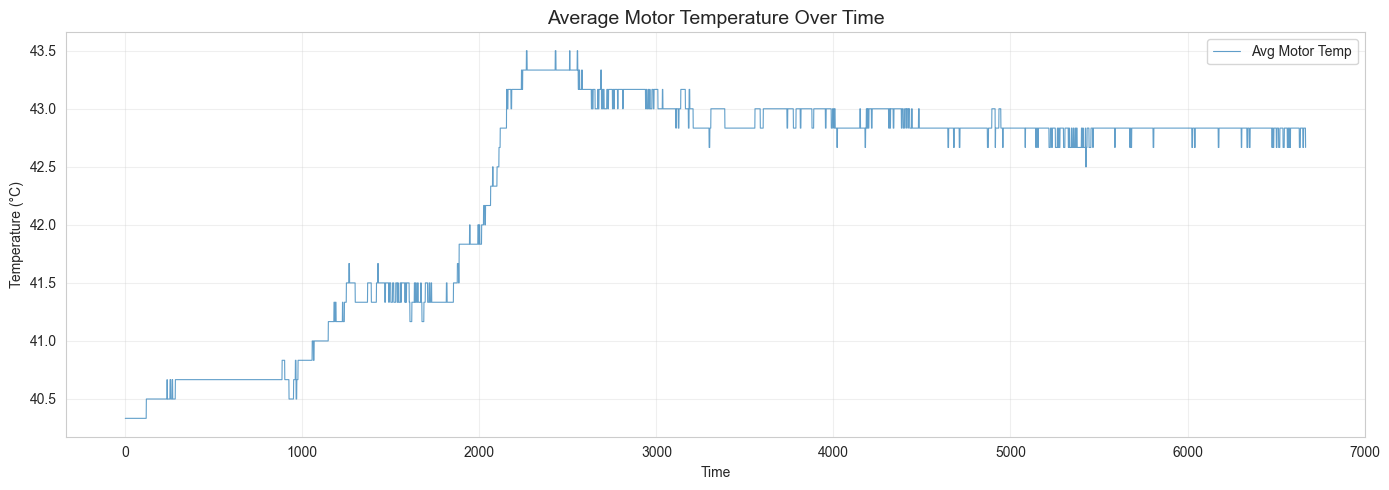

Start temp: 40.333333333333336°C
End temp: 42.666666666666664°C
Min: 40.333333333333336°C
Max: 43.5°C
Average: 42.3°C
Std: 0.93°C

Temperature change: +2.3°C
→ Robot appears to warm up during operation


In [12]:
print("="*80)
print("TEMPERATURE ANALYSIS")
print("="*80)

# Plot average motor temperature over time
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['avg_motor_temp'], linewidth=0.8, alpha=0.7, label='Avg Motor Temp')
plt.title('Average Motor Temperature Over Time', fontsize=14)
plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Basic stats
print(f"Start temp: {df['avg_motor_temp'].iloc[0]}°C")
print(f"End temp: {df['avg_motor_temp'].iloc[-1]}°C")
print(f"Min: {df['avg_motor_temp'].min()}°C")
print(f"Max: {df['avg_motor_temp'].max()}°C")
print(f"Average: {df['avg_motor_temp'].mean():.1f}°C")
print(f"Std: {df['avg_motor_temp'].std():.2f}°C")

# Check for warm-up
temp_change = df['avg_motor_temp'].iloc[-1] - df['avg_motor_temp'].iloc[0]
print(f"\nTemperature change: {temp_change:+.1f}°C")
if temp_change > 2:
    print("→ Robot appears to warm up during operation")
elif temp_change < -2:
    print("→ Robot appears to cool down")
else:
    print("→ Temperature relatively stable")

## Which Joints Moved?

In [13]:
print("="*80)
print("JOINT ACTIVITY")
print("="*80)

# Analyze each joint
joint_cols = ['j1', 'j2', 'j3', 'j4', 'j5', 'j6']

print("Joint movement analysis:")
print("-" * 50)
for joint in joint_cols:
    min_val = df[joint].min()
    max_val = df[joint].max()
    range_val = max_val - min_val
    std_val = df[joint].std()
    
    print(f"{joint}: Range={range_val:.3f} rad, Std={std_val:.4f}")
    if range_val < 0.01:
        print(f"  → {joint} appears STATIC")
    elif range_val < 0.1:
        print(f"  → {joint} has MINIMAL movement")
    else:
        print(f"  → {joint} is ACTIVE")

JOINT ACTIVITY
Joint movement analysis:
--------------------------------------------------
j1: Range=1.534 rad, Std=0.5471
  → j1 is ACTIVE
j2: Range=0.480 rad, Std=0.1486
  → j2 is ACTIVE
j3: Range=0.970 rad, Std=0.3526
  → j3 is ACTIVE
j4: Range=0.140 rad, Std=0.0468
  → j4 is ACTIVE
j5: Range=0.594 rad, Std=0.1610
  → j5 is ACTIVE
j6: Range=0.067 rad, Std=0.0137
  → j6 has MINIMAL movement


## Vibration Baseline

VIBRATION SUMMARY


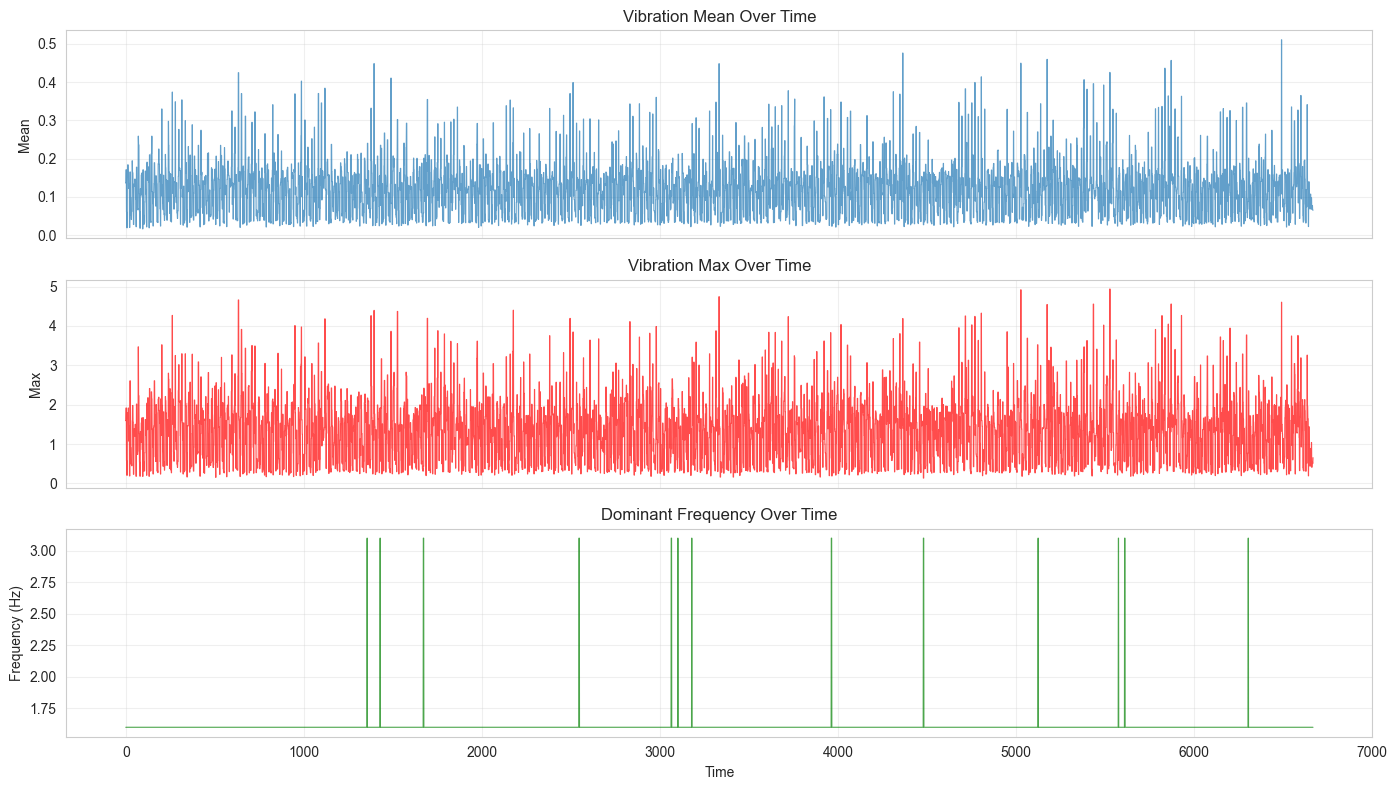

Mean vibration: 0.1203 (±0.0769)
Max vibration: 1.3113 (±0.9019)
Dominant freq: 1.61 Hz (±0.10)

Vibration spikes (>2σ): 283


In [14]:
print("="*80)
print("VIBRATION SUMMARY")
print("="*80)

# Plot vibration summary stats
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df.index, df['vib_mean'], linewidth=0.8, alpha=0.7)
axes[0].set_ylabel('Mean')
axes[0].set_title('Vibration Mean Over Time')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df.index, df['vib_max'], linewidth=0.8, alpha=0.7, color='red')
axes[1].set_ylabel('Max')
axes[1].set_title('Vibration Max Over Time')
axes[1].grid(True, alpha=0.3)

axes[2].plot(df.index, df['dominant_freq'], linewidth=0.8, alpha=0.7, color='green')
axes[2].set_ylabel('Frequency (Hz)')
axes[2].set_title('Dominant Frequency Over Time')
axes[2].set_xlabel('Time')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Basic stats
print(f"Mean vibration: {df['vib_mean'].mean():.4f} (±{df['vib_mean'].std():.4f})")
print(f"Max vibration: {df['vib_max'].mean():.4f} (±{df['vib_max'].std():.4f})")
print(f"Dominant freq: {df['dominant_freq'].mean():.2f} Hz (±{df['dominant_freq'].std():.2f})")

# Identify spikes
vib_threshold = df['vib_max'].mean() + 2 * df['vib_max'].std()
spikes = df[df['vib_max'] > vib_threshold]
print(f"\nVibration spikes (>2σ): {len(spikes)}")


## Pressure Check

PRESSURE ANALYSIS


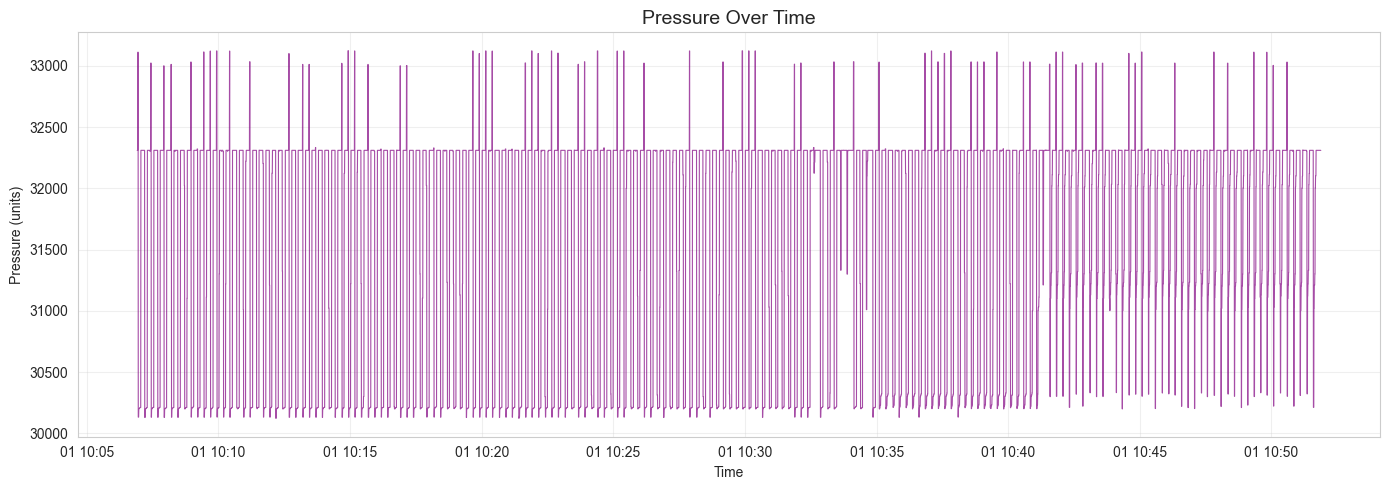

Min pressure: 30123
Max pressure: 33123
Mean: 31632.83
Std: 966.1586

Unique pressure values: 172
→ Pressure VARIES during operation

⚠️ Found 225 sudden pressure drops:


,timestamp,pressure
6,2025-12-01 10:06:57.320423,30133
43,2025-12-01 10:07:12.137292,30130
80,2025-12-01 10:07:26.964484,30132
117,2025-12-01 10:07:41.840658,30131
153,2025-12-01 10:07:56.262625,30131


In [15]:
print("="*80)
print("PRESSURE ANALYSIS")
print("="*80)

plt.figure(figsize=(14, 5))
plt.plot(df['timestamp'], df['pressure'], linewidth=0.8, alpha=0.7, color='purple')
plt.title('Pressure Over Time', fontsize=14)
plt.xlabel('Time')
plt.ylabel('Pressure (units)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Min pressure: {df['pressure'].min()}")
print(f"Max pressure: {df['pressure'].max()}")
print(f"Mean: {df['pressure'].mean():.2f}")
print(f"Std: {df['pressure'].std():.4f}")

# Check if pressure varies or is constant
unique_values = df['pressure'].nunique()
print(f"\nUnique pressure values: {unique_values}")

if unique_values == 1:
    print("→ Pressure is CONSTANT (no variation)")
elif unique_values < 10:
    print("→ Pressure has FEW discrete values")
else:
    print("→ Pressure VARIES during operation")
    
# Check for sudden drops (potential suction failures!)
pressure_drops = df['pressure'].diff()
large_drops = pressure_drops[pressure_drops < -10]  # Adjust threshold as needed
if len(large_drops) > 0:
    print(f"\n⚠️ Found {len(large_drops)} sudden pressure drops:")
    display(df.loc[large_drops.index][['timestamp', 'pressure']].head())
else:
    print("\n✓ No sudden pressure drops detected")